In [1]:
import plotly.tools as tls
import plotly.offline as py
import plotly.graph_objs as go
from dataset import TimeSeriesDataset, TimeSeriesNode
from PIL import Image

py.init_notebook_mode(connected=True)


In [2]:
dataset = TimeSeriesDataset(train_ratio=0.75, kind='acc', shuffle_mode=1)

100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [00:35<00:00,  1.78it/s]


('Dataset Statistics:\n', "All:('Dataset Lenght:761', 'Label_mean:4.0')\n", "Train:('Dataset Lenght:570', 'Label_mean:4.0')\n", "Test :('Dataset Lenght:191', 'Label_mean:4.0')\n")


In [27]:
len(dataset.readings)

825

In [31]:
readings_dict

{34: <dataset.TimeSeriesNode at 0x1f19bd32e80>,
 23: <dataset.TimeSeriesNode at 0x1f19be644e0>,
 62: <dataset.TimeSeriesNode at 0x1f19be1a940>,
 60: <dataset.TimeSeriesNode at 0x1f19be64d30>,
 37: <dataset.TimeSeriesNode at 0x1f19be51da0>,
 18: <dataset.TimeSeriesNode at 0x1f19be510b8>,
 55: <dataset.TimeSeriesNode at 0x1f19be69cc0>,
 30: <dataset.TimeSeriesNode at 0x1f19d259278>,
 17: <dataset.TimeSeriesNode at 0x1f19be69978>,
 35: <dataset.TimeSeriesNode at 0x1f19be69080>,
 52: <dataset.TimeSeriesNode at 0x1f19d256a90>,
 25: <dataset.TimeSeriesNode at 0x1f19d256898>,
 19: <dataset.TimeSeriesNode at 0x1f19d259390>,
 53: <dataset.TimeSeriesNode at 0x1f19be69278>,
 28: <dataset.TimeSeriesNode at 0x1f19d256e10>,
 61: <dataset.TimeSeriesNode at 0x1f19d251908>,
 32: <dataset.TimeSeriesNode at 0x1f19be69f98>,
 20: <dataset.TimeSeriesNode at 0x1f19d229978>,
 40: <dataset.TimeSeriesNode at 0x1f19d229dd8>,
 24: <dataset.TimeSeriesNode at 0x1f19d2507b8>,
 2: <dataset.TimeSeriesNode at 0x1f19d24

In [51]:
hover_infos.__len__()

64


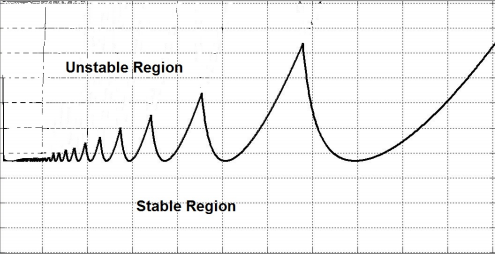

In [55]:
from collections import OrderedDict
xs = []
ys = []
zs = []
hover_infos = []
readings_dict = dict()
for reading in dataset.readings:
    if reading.time=='00':
        readings_dict[reading.slotno] = reading

for reading in readings_dict.values():  # type:TimeSeriesNode
    
    if reading.time == '00':
        xs += [reading.spindle_speed]
        ys += [reading.depth_of_cut]
        zs += [reading.var]
        
        if reading.slotno%2==1:
#             hover_infos += [f"{reading.hover_information} <br /> {readings_dict[reading.slotno+1].hover_information}"]
                hover_infos += [reading.hover_information]
        else:
#             hover_infos += [f"{readings_dict[reading.slotno-1].hover_information} <br /> {reading.hover_information}"]
                hover_infos += ["sgds"]

        


    
base_trace = go.Scatter(x=xs,
                        y=ys,
                        mode='markers',
                        hoverinfo='text',
                        hovertext=hover_infos,
                        hoverlabel= dict(bgcolor='black', font=dict(color='white')),
                        marker=dict(color='White', size=10))

heatmap_trace = go.Heatmap(x=xs,
                          y=ys,
                          z=zs,
                          zsmooth='best',
                          hoverinfo='none')



image = Image.open('../images/stability_lobs.png')
layout= go.Layout(images= [dict(
                              source= image,
                              xref= "x",
                              yref= "y",
                              x= 2000,
                              y= 20, # from y to y-sizey
                              sizex= 13000,
                              sizey= 20,
                              sizing= "stretch",
                              opacity= 0.5,
                              layer= "below")])

fig=go.Figure(data=[base_trace, heatmap_trace],layout=layout)
fig.show()

In [40]:
dataset.readings[1].slotname

'kanal34'

In [41]:
dataset.readings[1].time

'04'

In [57]:
import pandas as pd

In [58]:
pd.read_csv("../input/preprocessed_data/alu_v2/dash_data.csv")

,clearance_factor,crest_factor,impulse_factor,index_of_dispersion,kurtosis,rms,shape_factor,skew,var,vpeak,label,slotname,time
0,42.781289,5.118099,6.442549,4.538256,0.115779,0.189563,1.258778,-0.061405,0.035872,0.970201,4,kanal1,0
1,42.546177,5.146114,6.509287,4.356984,0.222496,0.193520,1.264894,0.015769,0.037377,0.995878,4,kanal10,0
2,34.836689,4.788134,6.077595,6.531006,0.266886,0.221442,1.269304,-0.093620,0.048980,1.060295,4,kanal11,0
3,40.002310,5.460442,6.893821,6.908951,0.141019,0.217574,1.262502,-0.048524,0.047292,1.188050,4,kanal12,0
4,30.698731,4.848719,6.272448,12.039409,0.705722,0.264318,1.293630,0.069701,0.069830,1.281604,4,kanal13,0
5,35.531306,7.044804,9.312077,30.013375,2.185213,0.346428,1.321836,-0.123323,0.119996,2.440518,4,kanal14,0
6,41.425907,4.775244,6.019833,4.721784,0.147565,0.183190,1.260634,-0.075924,0.033508,0.874776,4,kanal15,0
7,45.779314,5.205032,6.591673,2.632372,0.267146,0.182347,1.266404,-0.070450,0.033092,0.949122,4,kanal16,0
8,34.667285,4.681897,5.896836,3.575183,0.104185,0.214238,1.259497,-0.069908,0.045734,1.003040,4,kanal17,0
9,39.324528,5.281353,6.631194,3.745592,0.042537,0.211726,1.255586,-0.042119,0.044686,1.118201,4,kanal18,0
